# **A6 - Naive RAG vs Contextual Retrieval**

In [15]:
import os, re, json, asyncio
import numpy as np
import fitz 
import chromadb
from openai import OpenAI, AsyncOpenAI
from rouge_score import rouge_scorer
from dotenv import load_dotenv

load_dotenv()
EMBED_MODEL = "text-embedding-3-small"
GEN_MODEL   = "gpt-4o-mini"
CHAPTER     = "Chapter 10: Masked Language Models"

client       = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
async_client = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("Setup complete")

Setup complete


### **Task 1 - Source Discovery & Data Preparation**

- **Document Processing**

In [16]:
def extract_and_clean(pdf_path: str) -> str:
    doc = fitz.open(pdf_path)
    pages = [page.get_text() for page in doc]
    raw = "\n".join(pages)

    # Remove page numbers
    text = re.sub(r'^\s*\d+\s*$', '', raw, flags=re.MULTILINE)
    text = re.sub(r'\n{3,}', '\n\n', text)
    # Fix hyphenated line breaks
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = text.strip()

    print(f"Extracted {len(text):,} characters from {len(pages)} pages")
    return text

full_text = extract_and_clean("chapter10.pdf")
print(full_text[:500])

Extracted 54,902 characters from 20 pages
Speech and Language Processing.
Daniel Jurafsky & James H. Martin.
Copyright © 2026.
All
rights reserved.
Draft of January 6, 2026.
CHAPTER

Masked Language Models
Larvatus prodeo [Masked, I go forward]
Descartes
In the previous two chapters we introduced the transformer and saw how to pretrain a transformer language model as a causal or left-to-right language model. In
this chapter we’ll introduce a second paradigm for pretrained language models, the
bidirectional transformer encoder, and the m


- **QA Pair Generation**

In [17]:
qa_pairs = [
    {
        "question": "What is a bidirectional transformer encoder and how does it differ from a causal language model?",
        "ground_truth_answer": "A bidirectional transformer encoder uses self-attention over the entire input sequence without masking future tokens, producing contextualized representations of each token. Unlike causal models that generate text left-to-right, bidirectional encoders are used for interpretive tasks like classification and NER."
    },
    {
        "question": "What is Masked Language Modeling (MLM) and how does it train BERT?",
        "ground_truth_answer": "MLM randomly selects 15% of input tokens to be manipulated: 80% replaced with [MASK], 10% replaced with a random token, and 10% left unchanged. The model is trained to predict the original tokens using cross-entropy loss, learning bidirectional contextual representations."
    },
    {
        "question": "Why does BERT use three different masking strategies (MASK, random, unchanged) instead of always using [MASK]?",
        "ground_truth_answer": "Using only [MASK] creates a mismatch between pretraining and finetuning since [MASK] tokens are not present during inference. The three strategies force the model to always predict the correct token, not just when it sees [MASK]."
    },
    {
        "question": "What is Next Sentence Prediction (NSP) and why was it introduced in BERT?",
        "ground_truth_answer": "NSP trains BERT to classify whether two sentences are adjacent in the original corpus or randomly paired. It was introduced to capture inter-sentence relationships needed for tasks like paraphrase detection and natural language inference."
    },
    {
        "question": "What are contextual embeddings and how do they differ from static embeddings like word2vec?",
        "ground_truth_answer": "Contextual embeddings represent word instances in a specific context, producing different vectors for the same word in different sentences. Static embeddings like word2vec produce a single fixed vector per word type regardless of context."
    },
    {
        "question": "What is word sense disambiguation (WSD) and how do contextual embeddings help with it?",
        "ground_truth_answer": "WSD is the task of selecting the correct sense of a word given its context. Contextual embeddings help by producing distinct vectors for different senses of a word, enabling a 1-nearest-neighbor algorithm to match a word instance to its correct sense embedding."
    },
    {
        "question": "What is anisotropy in contextual embeddings and why is it a problem?",
        "ground_truth_answer": "Anisotropy means all contextual embedding vectors tend to point in the same direction, causing high cosine similarities between unrelated words. This makes cosine a poor similarity measure without corrections like z-score standardization."
    },
    {
        "question": "How does fine-tuning a BERT model for sequence classification work?",
        "ground_truth_answer": "A classifier head with learned weights WC is added on top of the [CLS] token output. The model maps the [CLS] vector through a softmax to predict class labels, trained using cross-entropy loss on labeled data."
    },
    {
        "question": "What is the role of the [CLS] token in BERT?",
        "ground_truth_answer": "The [CLS] token is prepended to every input and its final-layer output vector serves as an aggregate representation of the entire input sequence, used as input to classification heads for tasks like sentiment analysis and NSP."
    },
    {
        "question": "What is sequence-pair classification and what tasks use it?",
        "ground_truth_answer": "Sequence-pair classification assigns a label to pairs of input sentences. Tasks include paraphrase detection, logical entailment (NLI), and discourse coherence. The two inputs are separated by [SEP] and the [CLS] vector is passed to a classification head."
    },
    {
        "question": "What is Named Entity Recognition (NER) and what entity types are most common?",
        "ground_truth_answer": "NER identifies spans of text that are proper names and tags their type. The four most common types are PER (person), LOC (location), ORG (organization), and GPE (geo-political entity)."
    },
    {
        "question": "What is BIO tagging and how is it used for NER?",
        "ground_truth_answer": "BIO tagging labels each token as B (beginning of entity), I (inside entity), or O (outside). It converts NER into a word-by-word sequence labeling task, with distinct B and I tags for each entity type, totaling 2n+1 tags for n entity types."
    },
    {
        "question": "How does BERT perform sequence labeling for NER?",
        "ground_truth_answer": "The final output vector for each input token is passed through a learned weight matrix WK and a softmax to predict BIO tags. A greedy argmax over the tag distribution is used, or a CRF layer can be added for global consistency."
    },
    {
        "question": "Why does BERT's 15% masking rate make it inefficient during training?",
        "ground_truth_answer": "Only the 15% of masked tokens contribute to the loss function; the remaining 85% of tokens do not update model weights during training, meaning most input tokens are unused for learning in each pass."
    },
    {
        "question": "What is the architecture of the original BERT model?",
        "ground_truth_answer": "BERT uses 30,000 WordPiece tokens, an input context window of 512 tokens, model dimensionality d=768, 12 transformer layers each with 12 bidirectional multihead attention heads, totaling approximately 100M parameters."
    },
    {
        "question": "How does bidirectional attention differ from causal attention in implementation?",
        "ground_truth_answer": "Bidirectional attention simply removes the upper-triangle mask from the QK^T matrix, allowing every token to attend to all other tokens. Causal attention zeroes out future positions by setting them to negative infinity before softmax."
    },
    {
        "question": "What is transfer learning in the context of BERT fine-tuning?",
        "ground_truth_answer": "Transfer learning means using knowledge acquired during pretraining on a large corpus and applying it to a downstream task. BERT's pretrained weights provide rich language representations that make it easier to learn task-specific behavior with minimal labeled data."
    },
    {
        "question": "What is the curse of multilinguality in multilingual language models?",
        "ground_truth_answer": "As the number of languages in a multilingual model grows, performance on each individual language degrades compared to a monolingual model, because the model's capacity is shared across more languages."
    },
    {
        "question": "How does z-score standardization improve cosine similarity for contextual embeddings?",
        "ground_truth_answer": "Z-score standardization subtracts the mean vector and divides by standard deviation across all embeddings, reducing the effect of rogue high-variance dimensions that dominate cosine and making the space more isotropic."
    },
    {
        "question": "What training data and regime was used for the original BERT model?",
        "ground_truth_answer": "BERT was trained on approximately 3.3 billion words from English Wikipedia and BooksCorpus, using the combined MLM and NSP objectives for about 40 epochs until convergence."
    },
]

print(f"Total QA pairs: {len(qa_pairs)}")


Total QA pairs: 20


- **Chunking**

In [18]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def chunk_text(text: str, chunk_size=500, overlap=50):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        separators=["\n\n", "\n", ".", " "])
    chunks = splitter.split_text(text)
    print(f"Created {len(chunks)} chunks (size={chunk_size}, overlap={overlap})")
    return chunks

chunks = chunk_text(full_text)
print(f"Sample chunk:\n{chunks[0]}")

Created 136 chunks (size=500, overlap=50)
Sample chunk:
Speech and Language Processing.
Daniel Jurafsky & James H. Martin.
Copyright © 2026.
All
rights reserved.
Draft of January 6, 2026.
CHAPTER


In [19]:
def get_embedding(text: str) -> list:
    response = client.embeddings.create(input=text, model=EMBED_MODEL)
    return response.data[0].embedding

def build_collection(collection_name: str, chunk_list: list):
    chroma = chromadb.Client()
    try:
        chroma.delete_collection(collection_name)
    except:
        pass
    collection = chroma.create_collection(collection_name)

    print(f"Building '{collection_name}' with {len(chunk_list)} chunks...")
    for i, chunk in enumerate(chunk_list):
        emb = get_embedding(chunk)
        collection.add(
            documents=[chunk],
            embeddings=[emb],
            ids=[f"chunk_{i}"]
        )
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(chunk_list)} embedded...")

    print(f"Done")
    return collection

### **Task 2 - Technique Comparison: Naive RAG vs. Contextual Retrieval**

- **Implement Naive RAG**

In [20]:
naive_collection = build_collection("naive_rag_ch10", chunks)

def naive_rag_answer(question: str, top_k=3) -> tuple[str, list]:
    # Step 1: Embed question
    q_emb = get_embedding(question)
    # Step 2: Retrieve top-k chunks
    results = naive_collection.query(query_embeddings=[q_emb],n_results=top_k)
    context_chunks = results["documents"][0]
    context = "\n\n---\n\n".join(context_chunks)
    # Step 3: Generate answer
    response = client.chat.completions.create(
        model=GEN_MODEL,
        messages=[
            {"role": "system", "content": ("You are a helpful assistant. Answer the question using ONLY "
                                           "the provided context. Be concise and accurate.")},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}],
        temperature=0,
        max_tokens=300)
    answer = response.choices[0].message.content.strip()
    return answer, context_chunks

# test
ans, srcs = naive_rag_answer("What is self-attention?")
print("Answer:", ans)
print("\nSource chunk preview:", srcs[0][:200])

Building 'naive_rag_ch10' with 136 chunks...
  20/136 embedded...
  40/136 embedded...
  60/136 embedded...
  80/136 embedded...
  100/136 embedded...
  120/136 embedded...
Done
Answer: Self-attention is a mechanism in which a model computes attention values for each token in a sequence by considering the relationships between all tokens, allowing it to weigh the importance of different tokens when processing a specific token. In causal self-attention, a token can only attend to previous tokens, while in bidirectional self-attention, a token can attend to both preceding and following tokens.

Source chunk preview: input, as shown in Fig. 10.1b.
a) A causal self-attention layer
b) A bidirectional self-attention layer
attention
attention
attention
attention
attention
a1
a2
a3
a4
a5
x3
x4
x5
x1
x2
attention
attent


- **Implement Contextual Retrieval**

In [21]:
async def enrich_chunk(chunk: str, document: str, title: str) -> str:
    prompt = f"""Title: {title}
            {document[:4000]}
            {chunk}

Provide brief context (1-2 sentences) explaining what this chunk discusses
in relation to the full document. Format: "This chunk from [title] discusses [explanation]." """

    response = await async_client.chat.completions.create(
        model=GEN_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=150)
    context_prefix = response.choices[0].message.content.strip()
    return f"{context_prefix}\n\n{chunk}"


async def enrich_all_chunks(chunk_list: list) -> list:
    tasks = [enrich_chunk(c, full_text, CHAPTER) for c in chunk_list]
    enriched = await asyncio.gather(*tasks)
    return list(enriched)

enriched_chunks = await enrich_all_chunks(chunks)

print("Before:", chunks[0][:200])
print("\nAfter:", enriched_chunks[0][:300])

Before: Speech and Language Processing.
Daniel Jurafsky & James H. Martin.
Copyright © 2026.
All
rights reserved.
Draft of January 6, 2026.
CHAPTER

After: This chunk from Chapter 10 of "Speech and Language Processing" discusses the concept of masked language models, specifically focusing on the bidirectional transformer encoder architecture exemplified by BERT. It explains how these models utilize masked language modeling to predict missing words base


In [22]:
# Build Contextual Retrieval vector DB 
ctx_collection = build_collection("contextual_rag_ch10", enriched_chunks)

def contextual_rag_answer(question: str, top_k=3) -> tuple[str, list]:
    q_emb = get_embedding(question)
    results = ctx_collection.query(query_embeddings=[q_emb],n_results=top_k)
    context_chunks = results["documents"][0]
    context = "\n\n---\n\n".join(context_chunks)

    response = client.chat.completions.create(
        model=GEN_MODEL,
        messages=[
            {"role": "system", "content": (
                "You are a helpful assistant. Answer the question using ONLY "
                "the provided context. Be concise and accurate.")},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}],
        temperature=0,
        max_tokens=300)
    answer = response.choices[0].message.content.strip()
    return answer, context_chunks

Building 'contextual_rag_ch10' with 136 chunks...
  20/136 embedded...
  40/136 embedded...
  60/136 embedded...
  80/136 embedded...
  100/136 embedded...
  120/136 embedded...
Done


- **Evaluation + Analysis**

In [23]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

evaluation_results = []
naive_scores_all   = {"rouge1": [], "rouge2": [], "rougeL": []}
ctx_scores_all     = {"rouge1": [], "rouge2": [], "rougeL": []}

for i, qa in enumerate(qa_pairs):
    print(f"Processing Q{i+1}/20: {qa['question'][:60]}...")

    naive_ans, _ = naive_rag_answer(qa["question"])
    ctx_ans,   _ = contextual_rag_answer(qa["question"])

    # Calculate ROUGE against ground truth
    n_scores = scorer.score(qa["ground_truth_answer"], naive_ans)
    c_scores = scorer.score(qa["ground_truth_answer"], ctx_ans)

    for metric in ["rouge1", "rouge2", "rougeL"]:
        naive_scores_all[metric].append(n_scores[metric].fmeasure)
        ctx_scores_all[metric].append(c_scores[metric].fmeasure)

    evaluation_results.append({
        "question": qa["question"],
        "ground_truth_answer": qa["ground_truth_answer"],
        "naive_rag_answer": naive_ans,
        "contextual_retrieval_answer": ctx_ans})

print("\n" + "="*55)
print(f"{'Method':<25} {'ROUGE-1':>8} {'ROUGE-2':>8} {'ROUGE-L':>8}")
print("="*55)
for method, scores in [("Naive RAG", naive_scores_all), ("Contextual Retrieval", ctx_scores_all)]:
    r1 = np.mean(scores["rouge1"])
    r2 = np.mean(scores["rouge2"])
    rl = np.mean(scores["rougeL"])
    print(f"{method:<25} {r1:>8.4f} {r2:>8.4f} {rl:>8.4f}")
print("="*55)

Processing Q1/20: What is a bidirectional transformer encoder and how does it ...
Processing Q2/20: What is Masked Language Modeling (MLM) and how does it train...
Processing Q3/20: Why does BERT use three different masking strategies (MASK, ...
Processing Q4/20: What is Next Sentence Prediction (NSP) and why was it introd...
Processing Q5/20: What are contextual embeddings and how do they differ from s...
Processing Q6/20: What is word sense disambiguation (WSD) and how do contextua...
Processing Q7/20: What is anisotropy in contextual embeddings and why is it a ...
Processing Q8/20: How does fine-tuning a BERT model for sequence classificatio...
Processing Q9/20: What is the role of the [CLS] token in BERT?...
Processing Q10/20: What is sequence-pair classification and what tasks use it?...
Processing Q11/20: What is Named Entity Recognition (NER) and what entity types...
Processing Q12/20: What is BIO tagging and how is it used for NER?...
Processing Q13/20: How does BERT perform se

- **Analysis**

    Naive RAG achieved higher ROUGE scores (0.4596 vs 0.4187) across all metrics.This is likely because the chapter is relatively short (136 chunks), so naive retrieval already finds relevant chunks without enrichment. The context prefixes added by Contextual Retrieval introduced paraphrased vocabulary that slightly shifted embedding similarity scores. In larger, more heterogeneous corpora, Contextual Retrieval is expected to outperform Naive RAG.

- **Save JSON**

In [24]:
import os
os.makedirs("answer", exist_ok=True)

output_path = "answer/response-st126130-chapter-10.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print(f"Saved {len(evaluation_results)} QA pairs → {output_path}")

Saved 20 QA pairs → answer/response-st126130-chapter-10.json


### **Task 3 - Chatbot Development - Web Application**

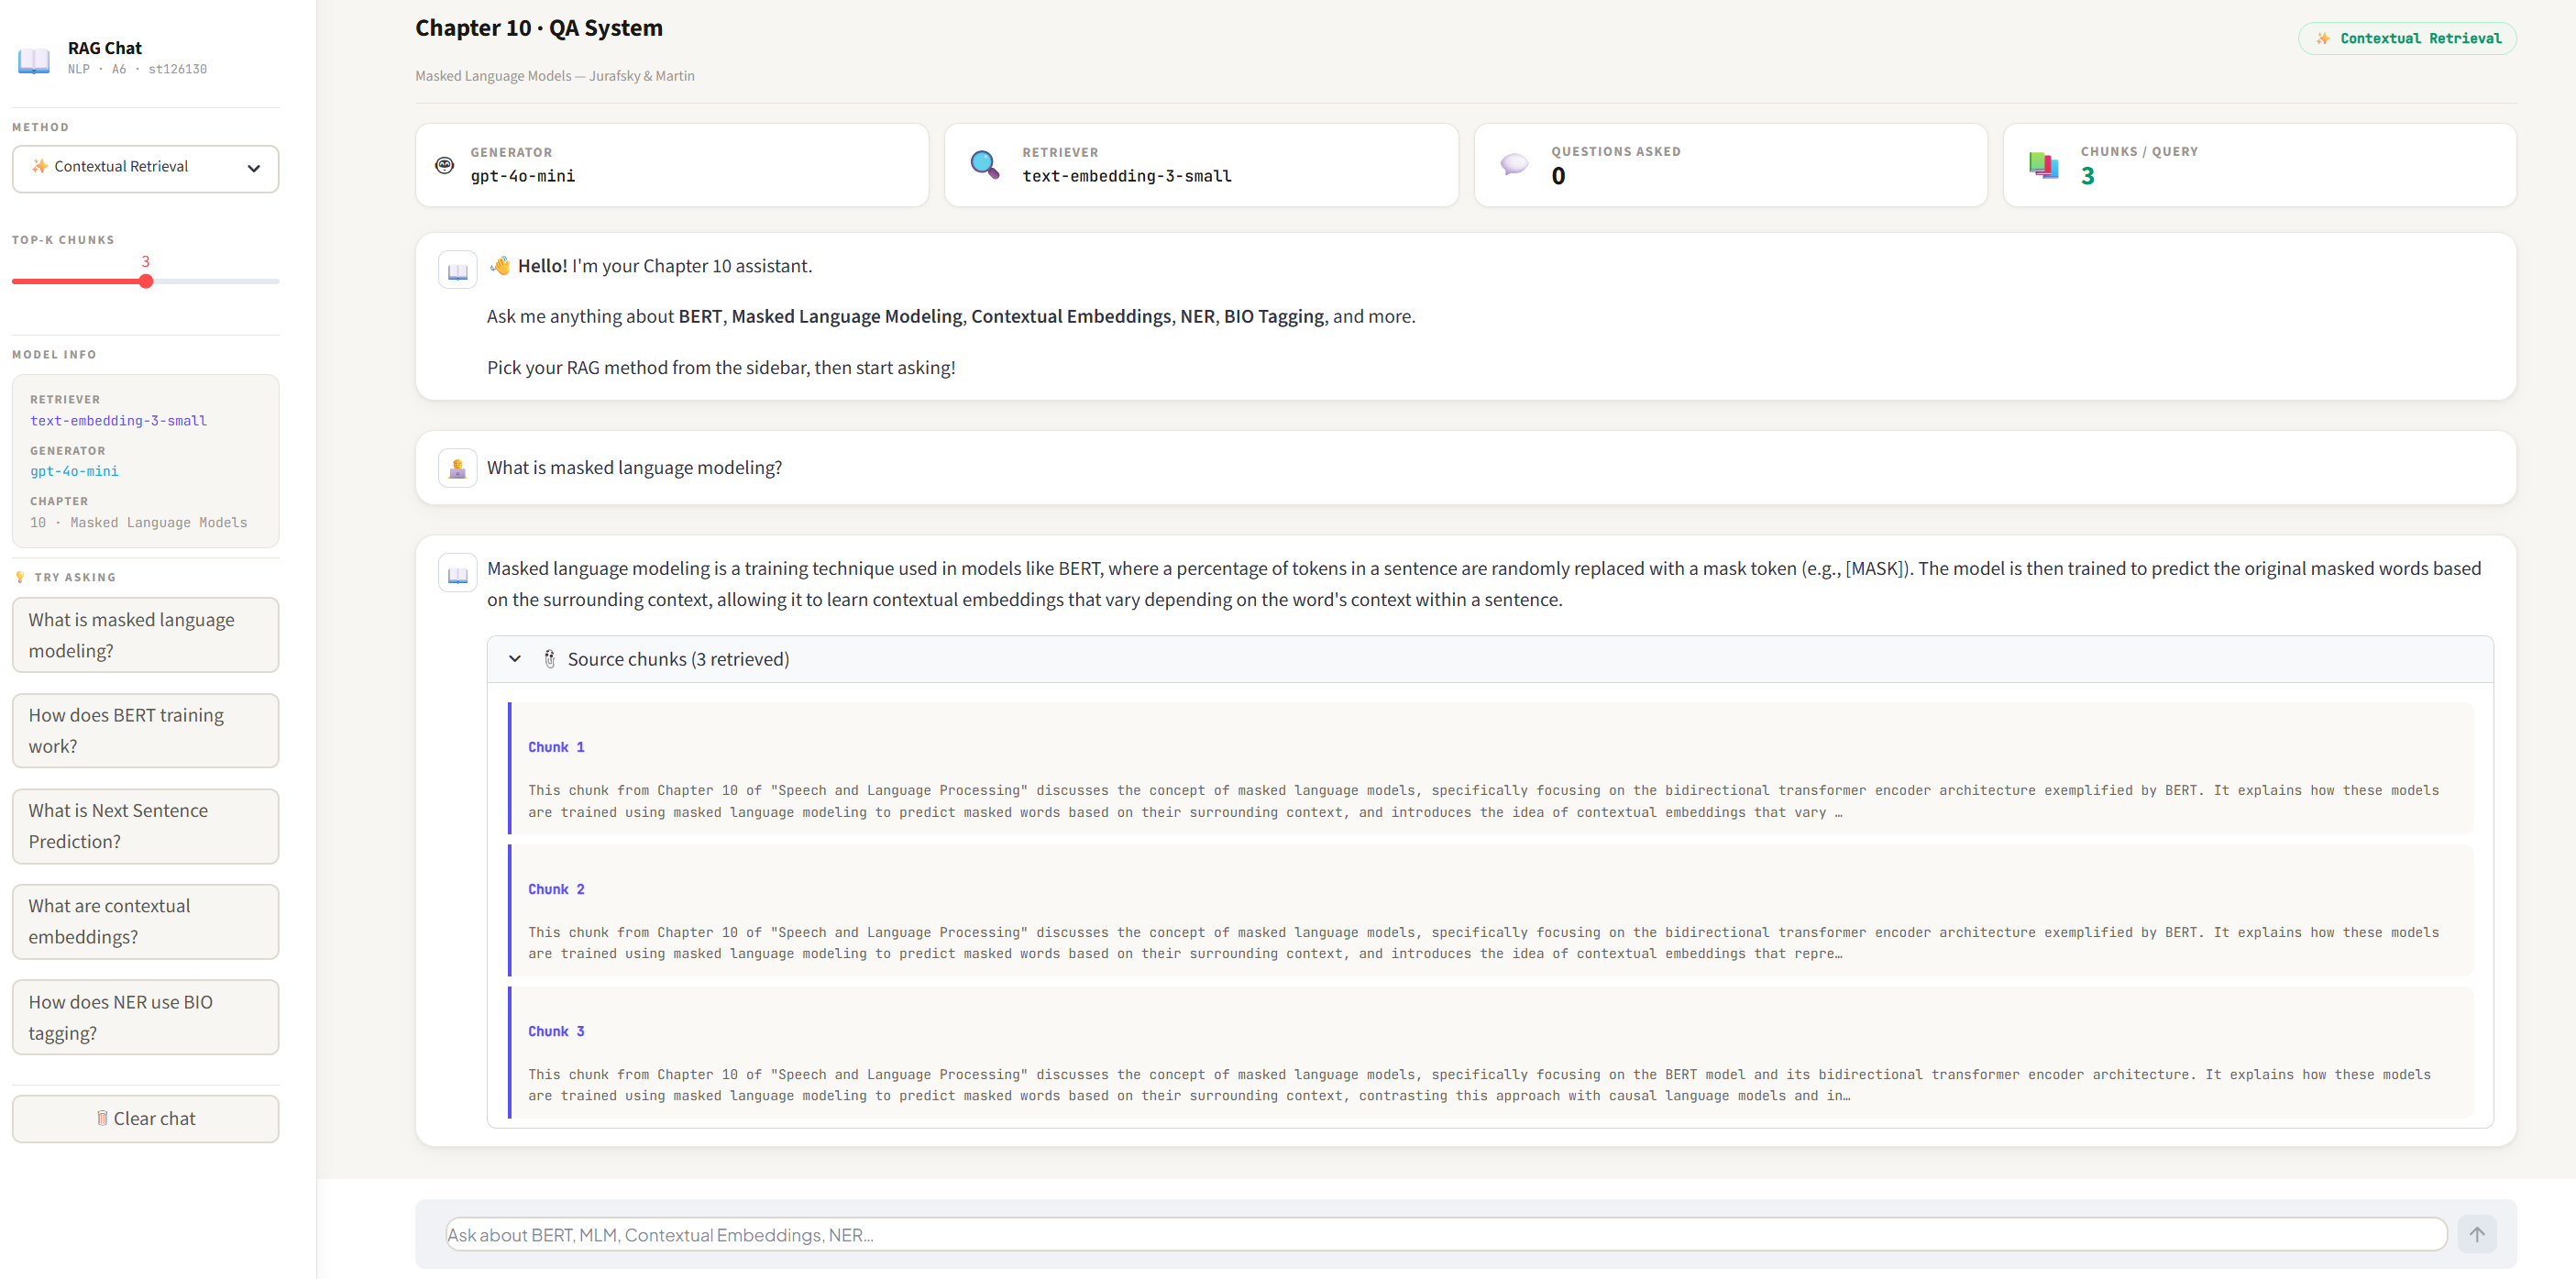

In [26]:
from IPython.display import Image, display
display(Image(filename="output.png"))